In [ ]:
# LDA

What is LDA?

Supervised dimensionality reduction technique.
Unlike PCA (unsupervised), LDA uses class labels.
Projects data in a way that maximizes class separability.

Goals:
Maximize between-class variance
Minimize within-class variance

Use Cases:
Preprocessing for classification
Visualization of high-dimensional data
Feature reduction

In [ ]:
S W−1. S B. w  = λ w

w are the eigenvectors (discriminant axes), and
λ are the eigenvalues.
After solving this equation, we get the eigenvectors (directions)
and eigenvalues (importance of each direction).

Thus, LDA is about finding directions (axes) in the feature space that
best separate the classes. These directions are the linear discriminants,
and they are computed by solving an eigenvalue problem


SyntaxError: invalid character '−' (U+2212) (2876223578.py, line 1)

### PCA looks for directions (components) that explain maximum variance in the data (regardless of the class labels), so it uses just the covariance matrix of the data.

### LDA focuses on maximizing the class separability, so it uses the within-class and between-class scatter matrices to find the best discriminant directions.

Classify flowers into 3 species based on petal and sepal measurements.
Lets say, we have many features, and we want to reduce the feature space — but not just for compression,
we want to retain what helps us distinguish the classes

[0.9912126 0.0087874]
This means LD1 explains ~99% of the separability, and LD2 only ~1%


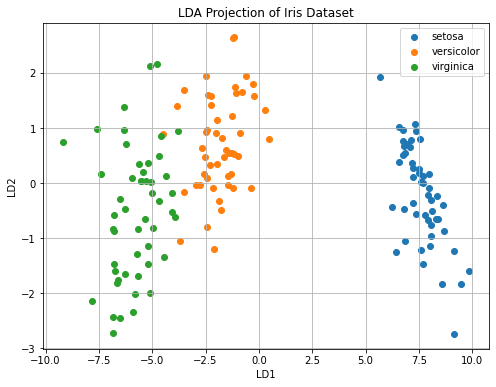

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2) # why 2?????
# Selecting the top n_components eigenvectors (those with highest eigenvalues)
# Projecting your data onto those vectors
# These eigenvectors become your new discriminant axes (LD1, LD2, etc).
X_lda = lda.fit_transform(X, y)

A = lda.explained_variance_ratio_
print(A)
print('This means LD1 explains ~99% of the separability, and LD2 only ~1%')

# Plot
plt.figure(figsize=(8,6))
for label in range(3):
    plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=data.target_names[label])
plt.legend()
plt.title("LDA Projection of Iris Dataset")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from numpy.linalg import eig
from sklearn.preprocessing import StandardScaler

# Center and scale
X_std = StandardScaler().fit_transform(X)
class_labels = np.unique(y)

# Compute means
mean_overall = np.mean(X_std, axis=0)
n_features = X_std.shape[1]
S_W = np.zeros((n_features, n_features))
S_B = np.zeros((n_features, n_features))

for label in class_labels:
    X_class = X_std[y == label]
    mean_class = np.mean(X_class, axis=0)
    # Within-class scatter
    S_W += np.dot((X_class - mean_class).T, (X_class - mean_class))
    # Between-class scatter
    n_class_samples = X_class.shape[0]
    mean_diff = (mean_class - mean_overall).reshape(n_features, 1)
    S_B += n_class_samples * (mean_diff).dot(mean_diff.T)

# Solve generalized eigenvalue problem
eig_vals, eig_vecs = eig(np.linalg.inv(S_W).dot(S_B))

# Sort eigenvalues by magnitude
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]

# Display eigenvalues
print("Eigenvalues (real part):", np.real(eig_vals))


Eigenvalues (real part): [3.21919292e+01 2.85391043e-01 2.01765204e-15 2.01765204e-15]


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Fit LDA to the standardized data
lda = LinearDiscriminantAnalysis()
lda.fit(X_std, y)

# Print LDA eigenvalues (explained variance ratio)
print("LDA explained variance ratio:", lda.explained_variance_ratio_)

# Access the scaling (eigenvectors)
print("LDA components (scaling or eigenvectors):", lda.scalings_[:, :2])


LDA explained variance ratio: [0.9912126 0.0087874]
LDA components (scaling or eigenvectors): [[ 0.68448644 -0.01989153]
 [ 0.66659193 -0.94029176]
 [-3.87282074  1.63962597]
 [-2.13508598 -2.15691008]]


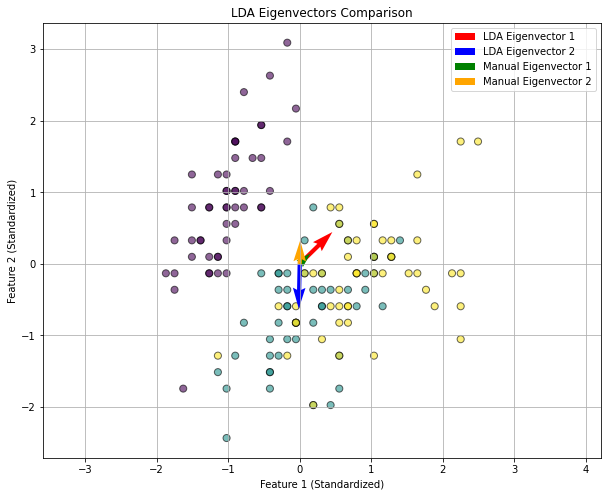

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset and standardize it
iris = load_iris()
X = iris.data
y = iris.target
X_std = StandardScaler().fit_transform(X)

# Fit LDA with sklearn
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_std, y)

# Manually compute eigenvalues and eigenvectors (same as in previous code)
class_labels = np.unique(y)
mean_overall = np.mean(X_std, axis=0)
n_features = X_std.shape[1]
S_W = np.zeros((n_features, n_features))
S_B = np.zeros((n_features, n_features))

for label in class_labels:
    X_class = X_std[y == label]
    mean_class = np.mean(X_class, axis=0)
    # Within-class scatter
    S_W += np.dot((X_class - mean_class).T, (X_class - mean_class))
    # Between-class scatter
    n_class_samples = X_class.shape[0]
    mean_diff = (mean_class - mean_overall).reshape(n_features, 1)
    S_B += n_class_samples * (mean_diff).dot(mean_diff.T)

# Solve generalized eigenvalue problem
eig_vals, eig_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

# Extract real parts of eigenvalues and eigenvectors
eig_vals = np.real(eig_vals)
eig_vecs = np.real(eig_vecs)

# Sort eigenvectors by eigenvalues
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]

# Plot the Iris dataset in the 2D space defined by the first two LDA components
plt.figure(figsize=(10, 8))

# Plot the dataset
plt.scatter(X_std[:, 0], X_std[:, 1], c=y, cmap='viridis', edgecolor='k', s=50, alpha=0.6)

# Plot the eigenvectors (directions) from sklearn LDA
plt.quiver(0, 0, lda.scalings_[0, 0], lda.scalings_[1, 0], angles='xy', scale_units='xy', scale=1.5, color='r', label='LDA Eigenvector 1')
plt.quiver(0, 0, lda.scalings_[0, 1], lda.scalings_[1, 1], angles='xy', scale_units='xy', scale=1.5, color='b', label='LDA Eigenvector 2')

# Plot the manually computed eigenvectors with increased scale
plt.quiver(0, 0, eig_vecs[0, 0], eig_vecs[1, 0], angles='xy', scale_units='xy', scale=1, color='g', label='Manual Eigenvector 1')
plt.quiver(0, 0, eig_vecs[0, 1], eig_vecs[1, 1], angles='xy', scale_units='xy', scale=1, color='orange', label='Manual Eigenvector 2')

# Labels and title
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.title('LDA Eigenvectors Comparison')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()



# An example

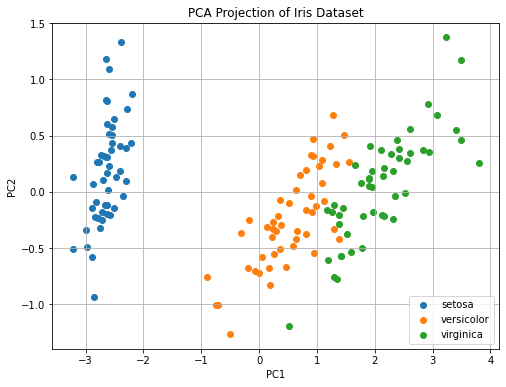

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot PCA
plt.figure(figsize=(8,6))
for label in range(3):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=data.target_names[label])
plt.legend()
plt.title("PCA Projection of Iris Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

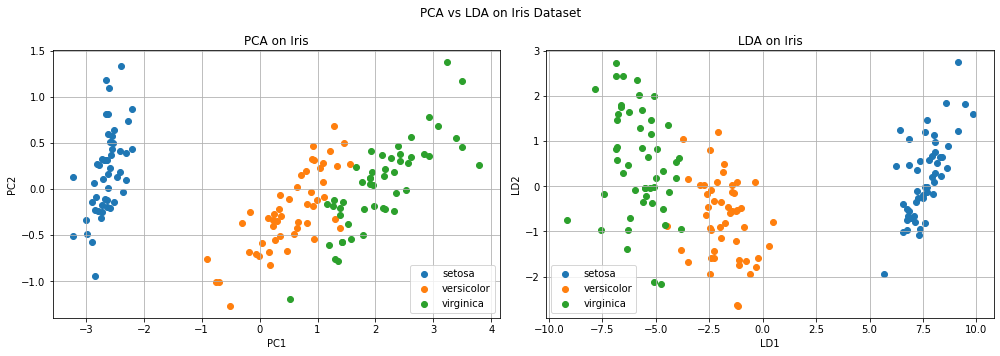

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

# Load data
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
print(X)

# PCA (unsupervised)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# LDA (supervised)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

# Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PCA Plot ---
for i, target in enumerate(np.unique(y)):
    axes[0].scatter(X_pca[y == target, 0], X_pca[y == target, 1], label=target_names[i])
axes[0].set_title('PCA on Iris')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# --- LDA Plot ---
for i, target in enumerate(np.unique(y)):
    axes[1].scatter(X_lda[y == target, 0], X_lda[y == target, 1], label=target_names[i])
axes[1].set_title('LDA on Iris')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("PCA vs LDA on Iris Dataset")
plt.tight_layout()
plt.show()


In PCA Plot:
X-axis = Principal Component 1 (PC1)
Y-axis = Principal Component 2 (PC2)
These are linear combinations of the original features, chosen to:
Maximize variance (spread of data)
Be orthogonal (independent)

So:
PC1 captures the direction of maximum variance in the data
PC2 captures the next most variance orthogonal to PC1
These components do not know about class labels

In LDA Plot:
X-axis = Linear Discriminant 1 (LD1)
Y-axis = Linear Discriminant 2 (LD2)
These are also linear combinations of original features, but:
They are computed to maximize the distance between class means (between-class scatter)
While minimizing variation within the same class (within-class scatter)

So:
LD1 is the best direction for separating the classes
LD2 adds additional class-discriminative power (if possible — only C - 1 axes max)


"Each axis is a linear combination of the input features, optimized for class separation. LD1 is the direction where the classes are most spread apart. LD2 gives additional separation if possible."

(178, 13)


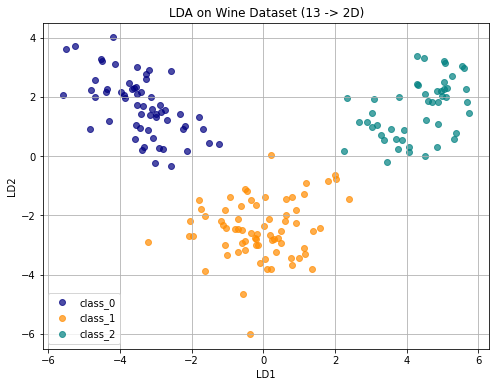

In [ ]:
# from 13 dimensions to 2D

from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

# Load data
wine = load_wine()
X = wine.data
print(X.shape)
y = wine.target
target_names = wine.target_names

# LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda.fit_transform(X, y)

# Plot
plt.figure(figsize=(8, 6))
colors = ['navy', 'darkorange', 'teal']
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_r2[y == i, 0], X_r2[y == i, 1], alpha=0.7, color=color, label=target_name)

plt.legend()
plt.title('LDA on Wine Dataset (13 -> 2D)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.grid(True)
plt.show()


Accuracy: 1.0


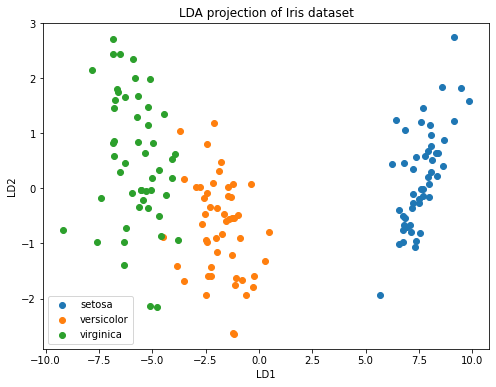

In [ ]:
# Using it with a classififer  (next step)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply LDA (4D gets reduce to 2D)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# Train/test split on LDA-reduced data
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, stratify=y, random_state=42)

# Classifier
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot LDA projection
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=iris.target_names[label])
plt.title("LDA projection of Iris dataset")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.show()

Accuracy without LDA: 0.9867
Accuracy with LDA:    0.9867


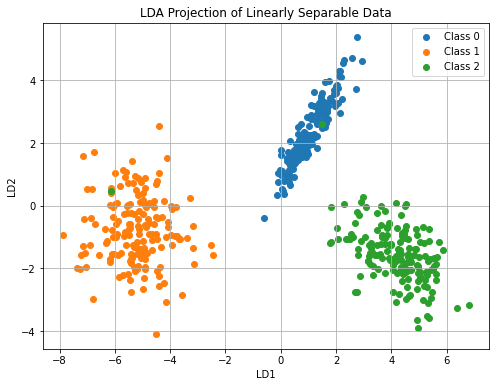

In [ ]:
# an example to show its next step (classification)

from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Generate linearly separable dataset
X, y = make_classification(
    n_samples=500,
    n_features=6,
    n_informative=3,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=2.5,
    random_state=42
)

# Train/test split on original data
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression without LDA
model_orig = LogisticRegression()
model_orig.fit(X_train_orig, y_train)
y_pred_orig = model_orig.predict(X_test_orig)
acc_orig = accuracy_score(y_test, y_pred_orig)

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

# Train/test split on LDA data
X_train_lda, X_test_lda, _, _ = train_test_split(X_lda, y, test_size=0.3, random_state=42)

# Logistic Regression with LDA
model_lda = LogisticRegression()
model_lda.fit(X_train_lda, y_train)
y_pred_lda = model_lda.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)

# Print Results
print(f"Accuracy without LDA: {acc_orig:.4f}")
print(f"Accuracy with LDA:    {acc_lda:.4f}")

# Visualization of LDA projection
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=f"Class {label}")
plt.title("LDA Projection of Linearly Separable Data")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Another example, now lets try showing the usability of LDA

# The 20 newsgroups dataset comprises around 18000 newsgroups posts on 20 topics split
# in two subsets: one for training (or development)
# and the other one for testing (or for performance evaluation)

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# Load a subset of categories
categories = ['sci.space', 'comp.graphics', 'rec.sport.baseball']
data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

# Convert to TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(data.data).toarray()
y = data.target


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Standardize features
X_std = StandardScaler().fit_transform(X)

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_std, y)


In [ ]:
from sklearn.model_selection import train_test_split

# Split original data (before LDA)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Split LDA-reduced data
X_train_lda, X_test_lda, y_train, y_test = train_test_split(X_lda, y, test_size=0.3, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression on original data
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Logistic Regression Accuracy (Original Data):", accuracy_score(y_test, y_pred))

# K-Nearest Neighbors on original data
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy (Original Data):", accuracy_score(y_test, y_pred_knn))

# Support Vector Machine on original data
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy (Original Data):", accuracy_score(y_test, y_pred_svm))

# Random Forest on original data
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy (Original Data):", accuracy_score(y_test, y_pred_rf))


Logistic Regression Accuracy (Original Data): 0.8855534709193246
KNN Accuracy (Original Data): 0.3433395872420263
SVM Accuracy (Original Data): 0.8893058161350844
Random Forest Accuracy (Original Data): 0.8424015009380863


In [ ]:
# Logistic Regression on LDA-reduced data
lr_lda = LogisticRegression()
lr_lda.fit(X_train_lda, y_train)
y_pred_lda = lr_lda.predict(X_test_lda)
print("Logistic Regression Accuracy (LDA Data):", accuracy_score(y_test, y_pred_lda))

# K-Nearest Neighbors on LDA-reduced data
knn_lda = KNeighborsClassifier(n_neighbors=5)
knn_lda.fit(X_train_lda, y_train)
y_pred_knn_lda = knn_lda.predict(X_test_lda)
print("KNN Accuracy (LDA Data):", accuracy_score(y_test, y_pred_knn_lda))

# Support Vector Machine on LDA-reduced data
svm_lda = SVC()
svm_lda.fit(X_train_lda, y_train)
y_pred_svm_lda = svm_lda.predict(X_test_lda)
print("SVM Accuracy (LDA Data):", accuracy_score(y_test, y_pred_svm_lda))

# Random Forest on LDA-reduced data
rf_lda = RandomForestClassifier(n_estimators=100)
rf_lda.fit(X_train_lda, y_train)
y_pred_rf_lda = rf_lda.predict(X_test_lda)
print("Random Forest Accuracy (LDA Data):", accuracy_score(y_test, y_pred_rf_lda))


Logistic Regression Accuracy (LDA Data): 0.9812382739212008
KNN Accuracy (LDA Data): 0.9812382739212008
SVM Accuracy (LDA Data): 0.9812382739212008
Random Forest Accuracy (LDA Data): 0.9812382739212008


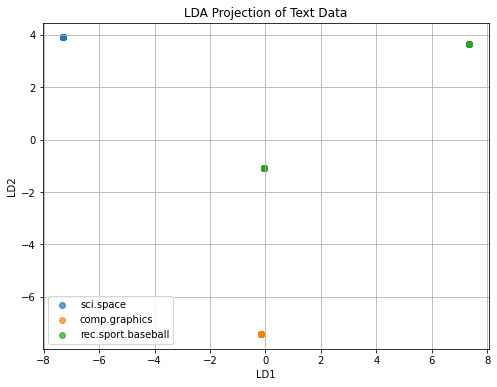

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for label in range(len(categories)):
    plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=categories[label], alpha=0.7)
plt.title("LDA Projection of Text Data")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# just a code to generate speech samples using google text to speech

from gtts import gTTS
import os

# Create audio file 1 (text-to-speech for the word "hello")
tts1 = gTTS("hello", lang='en')
tts1.save("audio_file_1.mp3")

# Create audio file 2 (text-to-speech for the word "world")
tts2 = gTTS("world", lang='en')
tts2.save("audio_file_2.mp3")

# Optionally, play the audio files using an external player (for testing)
# os.system("start audio_file_1.mp3")  # Windows
# os.system("afplay audio_file_1.mp3")  # macOS
# os.system("mpg321 audio_file_1.mp3")  # Linux


In [ ]:
# pip3 install librosa
# conda install -c conda-forge librosa


mfcc_1 [[-6.37170288e+02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-6.37170288e+02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-6.37170288e+02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-6.26688843e+02  1.47508240e+01  1.45373764e+01  1.41912727e+01
   1.37248650e+01  1.31520290e+01  1.24863644e+01  1.17403746e+01
   1.09258680e+01  1.00551805e+01  9.14267921e+00  8.20553017e+00
   7.26344156e+00]
 [-5.84498901e+02  5.33421898e+01  2.02820759e+01  1.04720860e+01
   1.10633574e+01  6.31557083e+00  8.31030178e+00  1.959866

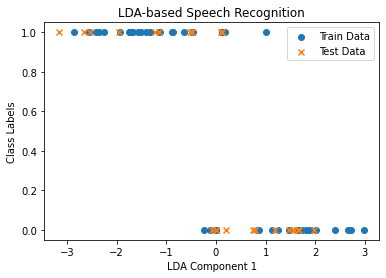

In [ ]:
# just another example using speech signal processing

import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load speech data (for demonstration purposes, use sample files or create your own dataset)
def extract_mfcc_features(audio_file):
    # Load the audio file
    y, sr = librosa.load(audio_file, sr=None)

    # Extract MFCC features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = mfcc.T  # Transpose to have time on rows and features on columns
    return mfcc

# Just inputting few input samples of speech
audio_file_1 = 'audio_file_1.mp3'  # Replace with actual file path
audio_file_2 = 'audio_file_2.mp3'  # Replace with actual file path

# Extract MFCC features from the audio files
mfcc_1 = extract_mfcc_features(audio_file_1)
mfcc_2 = extract_mfcc_features(audio_file_2)
print('mfcc_1',mfcc_1)

# Create a dataset (features and corresponding labels)
X = np.vstack([mfcc_1, mfcc_2])  # Stack the MFCC features vertically
y = np.array([0] * mfcc_1.shape[0] + [1] * mfcc_2.shape[0])  # Labels (0 for audio_file_1, 1 for audio_file_2)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply LDA for dimensionality reduction
lda = LinearDiscriminantAnalysis(n_components=1)  # Reduce to 1D for visualization
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Train a classifier (e.g., Support Vector Machine)
clf = SVC(kernel='linear')
clf.fit(X_train_lda, y_train)

# Predict and evaluate the model
y_pred = clf.predict(X_test_lda)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.2f}")

# Visualize the LDA results (for 2D plot if n_components=2)
plt.scatter(X_train_lda, y_train, label='Train Data')
plt.scatter(X_test_lda, y_test, label='Test Data', marker='x')
plt.title("LDA-based Speech Recognition")
plt.xlabel("LDA Component 1")
plt.ylabel("Class Labels")
plt.legend()
plt.show()


In [ ]:
#LDA for face recognition dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Loading dataset: faces with at least 70 images to have enough samples per class
lfw_dataset = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X = lfw_dataset.data
y = lfw_dataset.target
target_names = lfw_dataset.target_names
h, w = lfw_dataset.images[0].shape

print("Dataset size:")
print("Samples:", X.shape[0])
print("Features per image:", X.shape[1])
print("Number of classes:", len(target_names))

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

# Apply LDA (components = number of classes - 1)
lda = LinearDiscriminantAnalysis(n_components=len(np.unique(y)) - 1)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print(f"Reduced dimensionality from {X.shape[1]} to {X_train_lda.shape[1]}")

# Train a classifier (e.g., SVM)
clf = SVC(kernel='linear')
clf.fit(X_train_lda, y_train)
y_pred = clf.predict(X_test_lda)

# Evaluate
print("Classification report:\n", classification_report(y_test, y_pred, target_names=target_names))
print("Accuracy:", accuracy_score(y_test, y_pred))


Dataset size:
Samples: 1288
Features per image: 1850
Number of classes: 7
Reduced dimensionality from 1850 to 6
Classification report:
                    precision    recall  f1-score   support

     Ariel Sharon       0.79      0.58      0.67        19
     Colin Powell       0.71      0.68      0.70        59
  Donald Rumsfeld       0.36      0.50      0.42        30
    George W Bush       0.85      0.66      0.74       133
Gerhard Schroeder       0.53      0.70      0.60        27
      Hugo Chavez       0.56      0.56      0.56        18
       Tony Blair       0.56      0.81      0.66        36

         accuracy                           0.66       322
        macro avg       0.62      0.64      0.62       322
     weighted avg       0.70      0.66      0.67       322

Accuracy: 0.6583850931677019


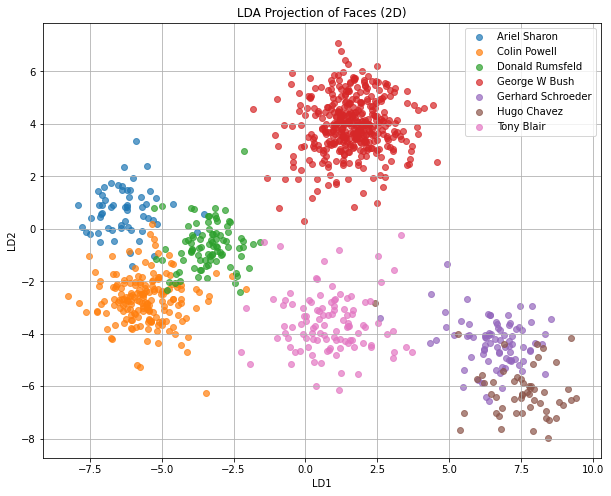

In [ ]:
# 2D Visualization (take 2 LDA components only for visualization)
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_lda_2d = lda_2d.fit_transform(X_train, y_train)

plt.figure(figsize=(10, 8))
for label in np.unique(y_train):
    plt.scatter(X_lda_2d[y_train == label, 0], X_lda_2d[y_train == label, 1], label=target_names[label], alpha=0.7)
plt.title("LDA Projection of Faces (2D)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.grid(True)
plt.show()


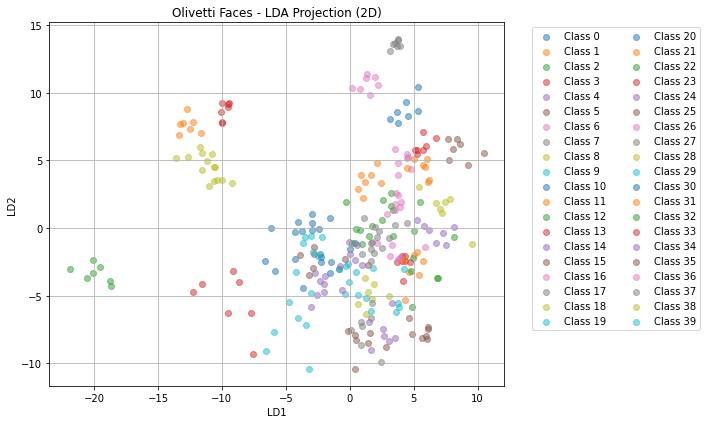

In [ ]:
# lets run

from sklearn.datasets import fetch_olivetti_faces
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load Olivetti Faces
data = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = data.data, data.target

# # Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

# # Apply LDA
# lda = LinearDiscriminantAnalysis(n_components=2)
# X_lda = lda.fit_transform(X_train, y_train)

# # Plot the LDA projection
# plt.figure(figsize=(10, 6))
# for label in np.unique(y_train):
#     plt.scatter(X_lda[y_train == label, 0], X_lda[y_train == label, 1], label=f'Class {label}', alpha=0.5)
# plt.title('Olivetti Faces - LDA Projection (2D)')
# plt.xlabel('LD1')
# plt.ylabel('LD2')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
# plt.tight_layout()
# plt.grid(True)
# plt.show()


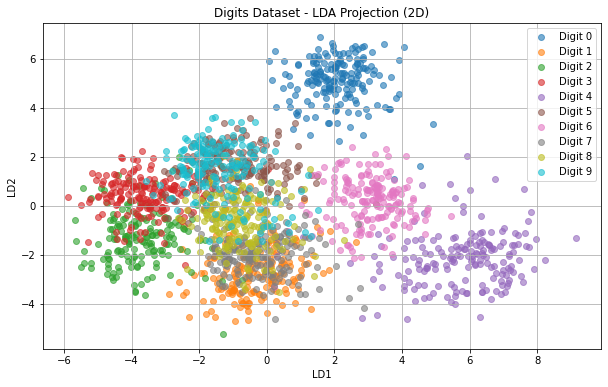

In [ ]:
from sklearn.datasets import load_digits
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# # Apply LDA
# lda = LinearDiscriminantAnalysis(n_components=2)
# X_lda = lda.fit_transform(X, y)

# # ➤ Maximum number of LDA components = number of classes - 1
# # Digits dataset has 10 classes (digits 0 through 9)
# # So LDA can reduce the data to at most 9 dimensions
# # In our example, we reduced it to just 2 components (for easy visualization).

# # Visualize LDA result
# plt.figure(figsize=(10, 6))
# for label in np.unique(y):
#     plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=f'Digit {label}', alpha=0.6)
# plt.title("Digits Dataset - LDA Projection (2D)")
# plt.xlabel("LD1")
# plt.ylabel("LD2")
# plt.legend()
# plt.grid(True)
# plt.show()



# FYI: Where it is being used in industries

1. Security & Surveillance
Panasonic – Face recognition systems (used Fisherfaces, based on LDA)
NEC Corporation – Biometrics and surveillance software
Face++ (Megvii) – Facial feature extraction pipelines

2. Healthcare & Biotech
GE Healthcare – Diagnostic imaging analysis
Philips – Clinical decision support systems
Roche / Illumina – Genomic data classification (e.g., cancer subtype detection)
NIH (National Institutes of Health) – Disease classification in medical research

3. Finance & Banking
FICO – Credit scoring systems
Experian – Risk analytics and fraud detection
Capital One – Customer credit behavior analysis

4. Manufacturing & Industrial IoT
Siemens – Fault detection and predictive maintenance
Bosch – Quality control systems using sensor data
General Electric (GE Digital) – Industrial asset monitoring

5. Retail & Telecom
AT&T – Customer churn prediction
Vodafone – Customer segmentation analysis
Target – Consumer behavior modeling

6. Academic & Government
NASA – Classification of satellite imagery
MIT Lincoln Laboratory – Signal classification and defense systems
US FDA / CDC – Research-based data classification models